In [5]:
import math
import matplotlib.pyplot as plt


In [27]:
import math


def generate_seat_positions(
    num_seats,
    seat_radius=10,
    row_spacing=22,
    inner_radius=90,
    aisles=2,
    aisle_width=30,
):
    """
    Generate semicircular legislative seating with straight aisles.

    Returns
    -------
    list[(x, y)]
    """

    # ----------------------------
    # Determine rows
    # ----------------------------

    rows = 1

    while True:

        capacity = 0

        for r in range(rows):

            radius = inner_radius + r * row_spacing

            capacity += math.floor(
                math.pi * radius / (seat_radius * 2.4)
            )

        if capacity >= num_seats:
            break

        rows += 1

    # Capacity per row

    row_capacities = []

    for r in range(rows):

        radius = inner_radius + r * row_spacing

        row_capacities.append(
            math.floor(
                math.pi * radius / (seat_radius * 2.4)
            )
        )

    # ----------------------------
    # Generate seats
    # ----------------------------

    seat_positions = []

    remaining = num_seats

    sections = aisles + 1

    for row in range(rows):

        radius = inner_radius + row * row_spacing

        seats = min(row_capacities[row], remaining)

        remaining -= seats

        if seats == 0:
            continue

        # Angular width occupied by a physical aisle
        aisle_angle = aisle_width / radius

        usable_angle = math.pi - aisles * aisle_angle

        section_angle = usable_angle / sections

        # Evenly divide seats among sections
        base = seats // sections
        extra = seats % sections

        seat_counts = [
            base + (1 if i < extra else 0)
            for i in range(sections)
        ]

        current_left = math.pi

        for count in seat_counts:

            current_right = current_left - section_angle

            if count == 1:

                angle = (current_left + current_right) / 2

                x = radius * math.cos(angle)
                y = radius * math.sin(angle)

                seat_positions.append((x, y))

            elif count > 1:

                # Arc available after leaving half a seat
                # against each aisle edge

                usable_arc = (
                    section_angle
                    - (seat_radius / radius)
                )

                step = usable_arc / (count - 1)

                start = current_left - seat_radius / (2 * radius)

                for i in range(count):

                    angle = start - i * step

                    x = radius * math.cos(angle)
                    y = radius * math.sin(angle)

                    seat_positions.append((x, y))

            current_left = current_right - aisle_angle

    return seat_positions

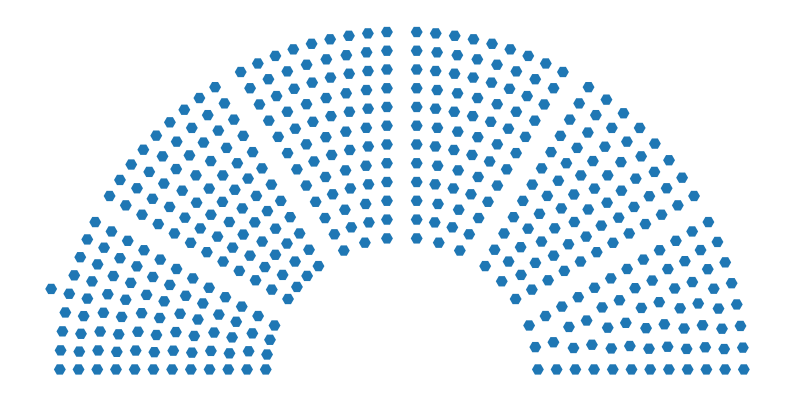

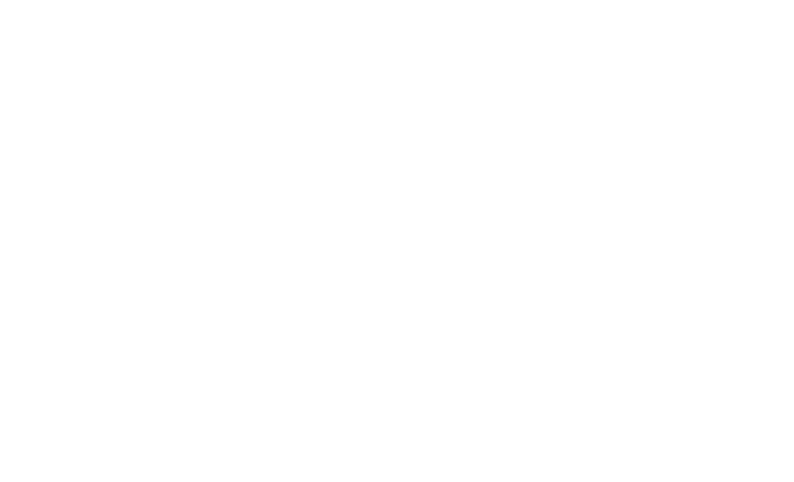

In [81]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import RegularPolygon

fig, ax = plt.subplots(figsize=(10, 6))

CIRCLE_SIZE = 200
seat_positions = generate_seat_positions(
    num_seats=435,
    # inner_radius=2,
    # seat_radius=16,
    # row_spacing=1,
    inner_radius=160,
    aisles=5,
    aisle_width=25,
)

xs = [x for x, _ in seat_positions]
ys = [y for _, y in seat_positions]

plt.figure(figsize=(10, 6))

# plt.scatter(xs, ys, s=CIRCLE_SIZE)

for x, y in seat_positions:
    ax.add_patch(
        RegularPolygon(
            (x, y),
            numVertices=6,
            radius=7,
            orientation=np.pi / 6,  # flat top
        )
    )

ax.set_aspect("equal")
ax.autoscale()
ax.axis("off")

# plt.gca().set_aspect("equal")
plt.axis("off")
plt.show()

In [82]:
import math
from xml.etree.ElementTree import Element, SubElement, ElementTree

HEX_RADIUS = 7

svg = Element(
    "svg",
    {
        "xmlns": "http://www.w3.org/2000/svg",
    },
)

for x, y in seat_positions:

    points = []

    # Flat-top hexagon
    for i in range(6):
        angle = math.pi / 6 + i * math.pi / 3
        px = x + HEX_RADIUS * math.cos(angle)
        py = -y + HEX_RADIUS * math.sin(angle)  # flip y for SVG

        points.append(f"{px:.2f},{py:.2f}")

    SubElement(
        svg,
        "polygon",
        {
            "points": " ".join(points),
            "fill": "#4C78A8",
            "stroke": "black",
            "stroke-width": "0.5",
        },
    )

ElementTree(svg).write("seats.svg")